<div style="background-color:#111827; color:#ffffff; padding:22px; border-left:7px solid #38bdf8; border-radius:10px;">

<h1 style="margin-top:0;">IBM HR Analytics: Employee Attrition & Performance</h1>

<p style="font-size:16px; margin-bottom:0;">
An end-to-end HR analytics project focused on understanding employee attrition patterns and preparing the dataset for machine learning-based attrition prediction.
</p>

</div>


## 1. Import Libraries

This section imports the Python libraries required for data loading, data cleaning, exploratory data analysis, visualization, preprocessing, and machine learning.


In [ ]:
import sys
print(sys.executable)
print(sys.version)

In [7]:
# install/check packages:
# %pip install pandas numpy matplotlib seaborn scikit-learn category_encoders kaggle

In [ ]:
import pandas as pd

import numpy as np

# pathlib = safe file path handling
from pathlib import Path

# matplotlib and seaborn = visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# warnings = hide unnecessary technical warnings
import warnings
warnings.filterwarnings("ignore")

# Show more columns/rows when displaying tables
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

# Show decimal numbers in a cleaner way
pd.set_option("display.float_format", "{:.3f}".format)

# Set a professional chart style
sns.set_theme(style="whitegrid", context="notebook")

# Default chart size
plt.rcParams["figure.figsize"] = (10, 5)

# Make chart titles bold
plt.rcParams["axes.titleweight"] = "bold"

# Random state keeps random results reproducible
RANDOM_STATE = 42

## 2. Load the Dataset

This section loads the IBM HR Analytics Employee Attrition dataset into a pandas DataFrame for analysis.


In [9]:
# The dataset is stored inside the local data folder
csv_path = Path("data/WA_Fn-UseC_-HR-Employee-Attrition.csv")

# Check whether Python can find the file
print("File exists:", csv_path.exists())

# Load CSV file into a pandas DataFrame
df_raw = pd.read_csv(csv_path)

# Print dataset size
print("Rows and columns:", df_raw.shape)

# Show first 5 rows
df_raw.head()

File exists: True
Rows and columns: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


## 3. Understand the Dataset

This section checks the basic structure of the dataset, including rows, columns, data types, and sample records.


In [10]:
# Display the first 5 rows
display(df_raw.head())

# Display the last 5 rows
display(df_raw.tail())

# Display all column names
df_raw.columns.tolist()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,3,Male,41,4,2,Laboratory Technician,4,Married,2571,12290,4,Y,No,17,3,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,4,Male,42,2,3,Healthcare Representative,1,Married,9991,21457,4,Y,No,15,3,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,2,Male,87,4,2,Manufacturing Director,2,Married,6142,5174,1,Y,Yes,20,4,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,4,Male,63,2,2,Sales Executive,2,Married,5390,13243,2,Y,No,14,3,4,80,0,17,3,2,9,6,0,8
1469,34,No,Travel_Rarely,628,Research & Development,8,3,Medical,1,2068,2,Male,82,4,2,Laboratory Technician,3,Married,4404,10228,2,Y,No,12,3,1,80,0,6,3,4,4,3,1,2


['Age',
 'Attrition',
 'BusinessTravel',
 'DailyRate',
 'Department',
 'DistanceFromHome',
 'Education',
 'EducationField',
 'EmployeeCount',
 'EmployeeNumber',
 'EnvironmentSatisfaction',
 'Gender',
 'HourlyRate',
 'JobInvolvement',
 'JobLevel',
 'JobRole',
 'JobSatisfaction',
 'MaritalStatus',
 'MonthlyIncome',
 'MonthlyRate',
 'NumCompaniesWorked',
 'Over18',
 'OverTime',
 'PercentSalaryHike',
 'PerformanceRating',
 'RelationshipSatisfaction',
 'StandardHours',
 'StockOptionLevel',
 'TotalWorkingYears',
 'TrainingTimesLastYear',
 'WorkLifeBalance',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager']

In [ ]:
# Step 4: Check data types and missing values

df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

## 4. Initial Data Quality Summary

This section checks missing values, constant columns, identifier columns, and the target variable before exploratory analysis.


In [12]:
quality_summary = pd.DataFrame({
    "data_type": df_raw.dtypes.astype(str),
    "missing_count": df_raw.isna().sum(),
    "missing_percent": df_raw.isna().mean() * 100,
    "unique_values": df_raw.nunique()
})

# Sort the table so suspicious columns appear clearly
quality_summary = quality_summary.sort_values(
    by=["missing_count", "unique_values"],
    ascending=[False, True]
)

quality_summary

,data_type,missing_count,missing_percent,unique_values
EmployeeCount,int64,0,0.000,1
Over18,object,0,0.000,1
StandardHours,int64,0,0.000,1
Attrition,object,0,0.000,2
Gender,object,0,0.000,2
OverTime,object,0,0.000,2
PerformanceRating,int64,0,0.000,2
BusinessTravel,object,0,0.000,3
Department,object,0,0.000,3
MaritalStatus,object,0,0.000,3


<div style="background-color:#111827; color:#ffffff; padding:18px; border-left:6px solid #38bdf8; border-radius:8px;">

<h2>🧹 Conclusion: Initial Data Quality Check</h2>

<p>The initial data quality check showed that the dataset is clean and ready for the next analysis steps.</p>

</div>

---

## ✅ Missing Values Check

The dataset contains **no missing values**.

This means we do not need to fill, replace, or remove missing values at this stage.

<div style="background-color:#111827; color:#ffffff; padding:16px; border-left:6px solid #22c55e; border-radius:8px;">

<h3>✅ Key Data Quality Finding</h3>

<p>No missing values were found in the dataset.</p>

<p>This reduces the need for additional missing-value treatment before exploratory analysis.</p>

</div>

---

## 🗑️ Removed Unnecessary Columns

Three columns contained only **one unique value** for all employees:

- `EmployeeCount`
- `Over18`
- `StandardHours`

These columns are not useful for machine learning because they do not create any difference between employees.

Since a machine learning model learns from differences in the data, these constant columns were removed.

---

## 🆔 Removed Identifier Column

The column `EmployeeNumber` was also removed because it is an employee ID.

It identifies each employee, but it does not describe employee behavior, satisfaction, income, overtime, or work history.

Therefore, it should not be used for prediction.

<div style="background-color:#111827; color:#ffffff; padding:16px; border-left:6px solid #f97316; border-radius:8px;">

<h3>⚠️ Why These Columns Were Removed</h3>

<p>Constant columns and ID columns do not provide useful predictive information.</p>

<p>Keeping them may add noise, unnecessary complexity, or misleading signals to the model.</p>

</div>

---

## 🎯 Target Column Preparation

The target column for this project is `Attrition`.

This column tells us whether an employee **left the company** or **stayed**.

Since machine learning models work better with numeric targets, `Attrition` was converted from text into numeric form.

| Original Value | Numeric Value | Meaning |
|---|---:|---|
| `Yes` | **1** | Employee left |
| `No` | **0** | Employee stayed |

<div style="background-color:#111827; color:#ffffff; padding:16px; border-left:6px solid #a855f7; border-radius:8px;">

<h3>🔢 Encoding Summary</h3>

<p><strong>Yes</strong> was converted to <strong>1</strong>, meaning the employee left.</p>

<p><strong>No</strong> was converted to <strong>0</strong>, meaning the employee stayed.</p>

</div>

---

## ✅ Final Takeaway

After removing unnecessary columns and encoding the target variable, the cleaned dataset is ready for:

- Exploratory data analysis
- Feature preprocessing
- Machine learning model development


In [14]:
# Create clean working dataset


# Start from the original loaded dataset
df_clean = df_raw.copy()

# These columns are removed because they are not useful for prediction
columns_to_drop = [
    "EmployeeCount",    # Same value for every employee
    "Over18",           # Same value for every employee
    "StandardHours",    # Same value for every employee
    "EmployeeNumber"    # ID column, not employee behavior
]

# Only drop columns that exist in the dataset
existing_columns_to_drop = [
    column for column in columns_to_drop
    if column in df_clean.columns
]

# Drop the selected columns
df_clean = df_clean.drop(columns=existing_columns_to_drop)

# Convert target column from text to number
# Yes = employee left = 1
# No = employee stayed = 0
df_clean["Attrition"] = df_clean["Attrition"].map({
    "Yes": 1,
    "No": 0
})

print("Dropped columns:", existing_columns_to_drop)
print("df_clean created successfully.")
print("Shape of df_clean:", df_clean.shape)

df_clean.head()

Dropped columns: ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber']
df_clean created successfully.
Shape of df_clean: (1470, 31)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Yes,11,3,1,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,No,23,4,4,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Yes,15,3,2,0,7,3,3,0,0,0,0
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Yes,11,3,3,0,8,3,3,8,7,3,0
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,No,12,3,4,1,6,3,3,2,2,2,2


# Part 2 | Exploratory Data Analysis (EDA)

This section explores attrition patterns across employee groups, roles, departments, income, satisfaction levels, work-life balance, and tenure.


In [15]:

# Step 10: Check attrition distribution

attrition_counts = df_clean["Attrition"].value_counts().rename(index={
    0: "Stayed",
    1: "Left"
})

attrition_rate = df_clean["Attrition"].mean() * 100

print("Attrition counts:")
display(attrition_counts)

print(f"Attrition rate: {attrition_rate:.2f}%")

Attrition counts:


Attrition
Stayed    1233
Left       237
Name: count, dtype: int64

Attrition rate: 16.12%


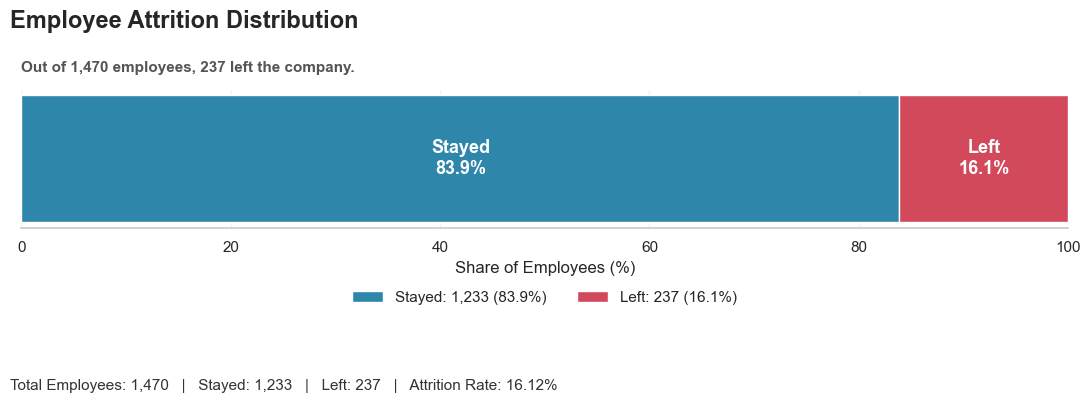

In [18]:

# Step 11: Attrition distribution

# Calculate key numbers
total_employees = len(df_clean)
employees_left = int(df_clean["Attrition"].sum())
employees_stayed = total_employees - employees_left

attrition_rate = employees_left / total_employees * 100
retention_rate = employees_stayed / total_employees * 100

# Create figure
fig, ax = plt.subplots(figsize=(11, 3.8))

# Colors
stayed_color = "#2E86AB"   # professional blue
left_color = "#D1495B"     # professional red

# Horizontal stacked bar
ax.barh(
    y=["Employees"],
    width=retention_rate,
    color=stayed_color,
    label=f"Stayed: {employees_stayed:,} ({retention_rate:.1f}%)"
)

ax.barh(
    y=["Employees"],
    width=attrition_rate,
    left=retention_rate,
    color=left_color,
    label=f"Left: {employees_left:,} ({attrition_rate:.1f}%)"
)

# Add percentage labels inside the bar
ax.text(
    retention_rate / 2,
    0,
    f"Stayed\n{retention_rate:.1f}%",
    ha="center",
    va="center",
    color="white",
    fontsize=13,
    fontweight="bold"
)

ax.text(
    retention_rate + attrition_rate / 2,
    0,
    f"Left\n{attrition_rate:.1f}%",
    ha="center",
    va="center",
    color="white",
    fontsize=13,
    fontweight="bold"
)

# Title and subtitle
fig.suptitle(
    "Employee Attrition Distribution",
    fontsize=17,
    fontweight="bold",
    x=0.01,
    ha="left"
)

ax.set_title(
    f"Out of {total_employees:,} employees, {employees_left:,} left the company.",
    fontsize=11,
    color="#555555",
    loc="left",
    pad=12
)

# KPI text below
kpi_text = (
    f"Total Employees: {total_employees:,}   |   "
    f"Stayed: {employees_stayed:,}   |   "
    f"Left: {employees_left:,}   |   "
    f"Attrition Rate: {attrition_rate:.2f}%"
)

fig.text(
    0.01,
    -0.02,
    kpi_text,
    fontsize=11,
    color="#333333"
)

# Clean formatting
ax.set_xlim(0, 100)
ax.set_xlabel("Share of Employees (%)")
ax.set_ylabel("")
ax.set_yticks([])

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.grid(axis="x", linestyle="--", alpha=0.25)
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.35),
    ncol=2,
    frameon=False
)

plt.tight_layout()
plt.show()

<div style="background-color:#111827; color:#ffffff; padding:18px; border-left:6px solid #38bdf8; border-radius:8px;">

<h2>📊 Conclusion: Attrition Distribution</h2>

<p>The dataset contains <strong>1,470 employees</strong> in total.</p>

<p>Out of these, <strong>1,233 employees stayed</strong> and <strong>237 employees left</strong> the company.</p>

</div>

---

## 📌 Attrition Summary

| Employee Status | Count |
|---|---:|
| Stayed | **1,233** |
| Left | **237** |
| Total | **1,470** |

<div style="background-color:#111827; color:#ffffff; padding:16px; border-left:6px solid #f97316; border-radius:8px;">

<h3>⚠️ Important Class Imbalance Finding</h3>

<p>The attrition rate is <strong>16.12%</strong>.</p>

<p>In simple terms, around <strong>16 out of every 100 employees</strong> left the company.</p>

</div>

---

## 🧠 Why This Matters for Machine Learning

The target variable is **imbalanced** because the number of employees who stayed is much larger than the number of employees who left.

This is important because a machine learning model could achieve high accuracy by mostly predicting that employees will stay.

<div style="background-color:#111827; color:#ffffff; padding:16px; border-left:6px solid #ef4444; border-radius:8px;">

<h3>🚨 Key Modeling Risk</h3>

<p>Accuracy alone may be misleading for this project.</p>

<p>A model could appear accurate while still failing to identify employees who are likely to leave.</p>

</div>

---

## ✅ Evaluation Strategy

For model evaluation, we should not rely only on accuracy.

Later, we will also use more professional evaluation metrics:

- **Precision**
- **Recall**
- **F1-score**
- **ROC-AUC**
- **PR-AUC**

<div style="background-color:#111827; color:#ffffff; padding:16px; border-left:6px solid #22c55e; border-radius:8px;">

<h3>✅ Final Takeaway</h3>

<p>Because the dataset is imbalanced, model performance should be evaluated using multiple metrics, especially <strong>recall, F1-score, ROC-AUC, and PR-AUC</strong>.</p>

</div>


,OverTime,employees,employees_left,attrition_rate,attrition_rate_percent
0,No,1054,110,0.104,10.436
1,Yes,416,127,0.305,30.529


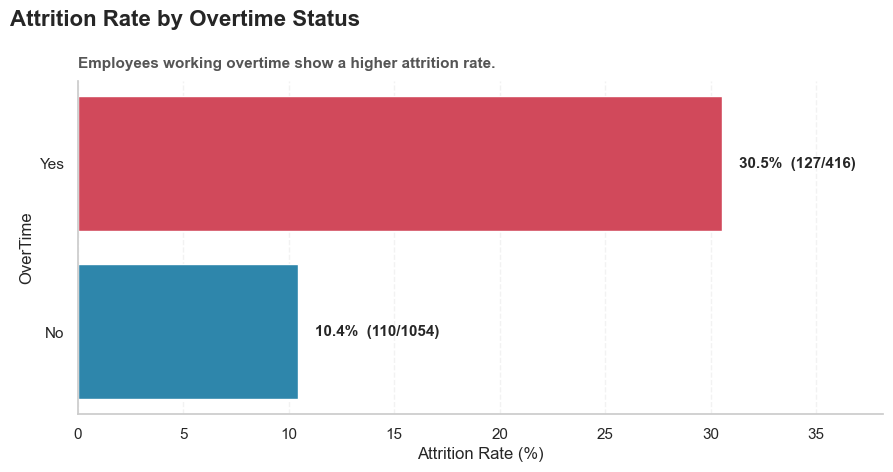

In [19]:
# Step 12: Attrition rate by OverTime


# Calculate attrition rate for each OverTime group
overtime_summary = (
    df_clean
    .groupby("OverTime")
    .agg(
        employees=("Attrition", "size"),
        employees_left=("Attrition", "sum"),
        attrition_rate=("Attrition", "mean")
    )
    .reset_index()
)

# Convert attrition rate to percentage
overtime_summary["attrition_rate_percent"] = overtime_summary["attrition_rate"] * 100

# Sort by attrition rate
overtime_summary = overtime_summary.sort_values(
    "attrition_rate_percent",
    ascending=True
)

display(overtime_summary)

# Create professional horizontal bar chart
fig, ax = plt.subplots(figsize=(9, 4.8))

bars = ax.barh(
    overtime_summary["OverTime"],
    overtime_summary["attrition_rate_percent"],
    color=["#2E86AB", "#D1495B"]
)

# Add labels at the end of bars
for bar, rate, left_count, total_count in zip(
    bars,
    overtime_summary["attrition_rate_percent"],
    overtime_summary["employees_left"],
    overtime_summary["employees"]
):
    ax.text(
        bar.get_width() + 0.8,
        bar.get_y() + bar.get_height() / 2,
        f"{rate:.1f}%  ({left_count}/{total_count})",
        va="center",
        fontsize=11,
        fontweight="bold"
    )

# Titles
fig.suptitle(
    "Attrition Rate by Overtime Status",
    fontsize=16,
    fontweight="bold",
    x=0.01,
    ha="left"
)

ax.set_title(
    "Employees working overtime show a higher attrition rate.",
    fontsize=11,
    color="#555555",
    loc="left",
    pad=10
)

# Axis formatting
ax.set_xlabel("Attrition Rate (%)")
ax.set_ylabel("OverTime")
ax.set_xlim(0, overtime_summary["attrition_rate_percent"].max() * 1.25)

# Clean formatting
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="x", linestyle="--", alpha=0.25)
ax.grid(axis="y", visible=False)

plt.tight_layout()
plt.show()

<div style="background-color:#111827; color:#ffffff; padding:18px; border-left:6px solid #ef4444; border-radius:8px;">

<h2>⏰ Conclusion: Attrition Rate by Overtime</h2>

<p>Employees who work <strong>overtime</strong> show a much higher attrition rate than employees who do not work overtime.</p>

</div>

---

## 📊 Attrition Summary by Overtime

| Overtime Status | Employees Who Left | Total Employees | Attrition Rate |
|---|---:|---:|---:|
| No overtime | **110** | **1,054** | **10.4%** |
| Overtime | **127** | **416** | **30.5%** |

<div style="background-color:#111827; color:#ffffff; padding:16px; border-left:6px solid #f97316; border-radius:8px;">

<h3>🚨 Key Insight</h3>

<p>The attrition rate for employees working overtime is almost <strong>three times higher</strong> than for employees who do not work overtime.</p>

<p>This suggests that <strong>OverTime</strong> is an important variable for understanding and predicting employee attrition.</p>

</div>

---

## 🧠 Business Interpretation

Employees working overtime may experience:

- Higher workload
- Increased stress
- Poorer work-life balance
- Lower recovery time
- Higher risk of burnout

This may explain why overtime employees show a higher attrition rate.

<div style="background-color:#111827; color:#ffffff; padding:16px; border-left:6px solid #facc15; border-radius:8px;">

<h3>⚠️ Important Caution</h3>

<p>This result should be interpreted as an <strong>association</strong>, not direct proof that overtime alone causes attrition.</p>

<p>Other factors may also influence employee attrition, such as:</p>

<ul>
<li>Job role</li>
<li>Salary</li>
<li>Job satisfaction</li>
<li>Department</li>
<li>Work-life balance</li>
</ul>

</div>

---

## ✅ Final Takeaway

`OverTime` appears to be one of the most important business signals related to employee attrition.

HR teams should monitor overtime workload carefully and investigate whether excessive overtime is contributing to higher employee turnover.


,BusinessTravel,employees,employees_left,attrition_rate,attrition_rate_percent
0,Non-Travel,150,12,0.080,8.000
2,Travel_Rarely,1043,156,0.150,14.957
1,Travel_Frequently,277,69,0.249,24.910


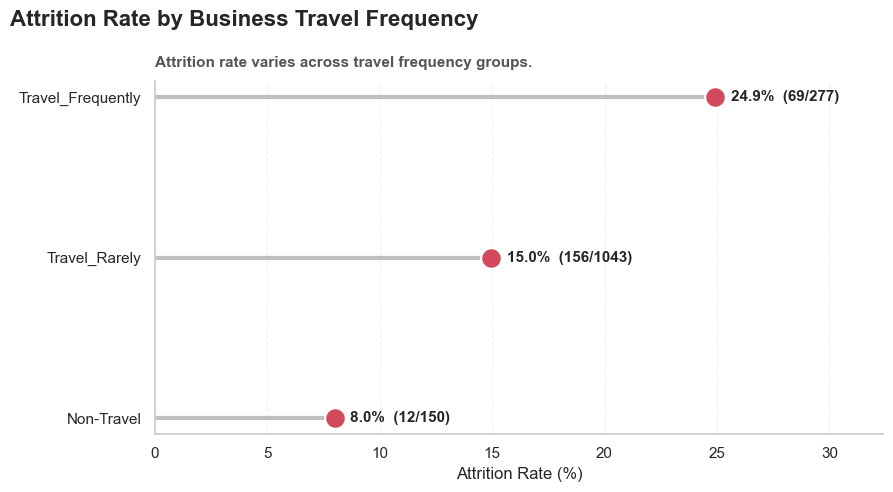

In [20]:

# Step 13: Attrition rate by Business Travel


# Calculate attrition summary by BusinessTravel group
travel_summary = (
    df_clean
    .groupby("BusinessTravel")
    .agg(
        employees=("Attrition", "size"),
        employees_left=("Attrition", "sum"),
        attrition_rate=("Attrition", "mean")
    )
    .reset_index()
)

# Convert attrition rate to percentage
travel_summary["attrition_rate_percent"] = travel_summary["attrition_rate"] * 100

# Sort by attrition rate
travel_summary = travel_summary.sort_values(
    "attrition_rate_percent",
    ascending=True
)

display(travel_summary)

# Create lollipop chart
fig, ax = plt.subplots(figsize=(9, 5))

# Horizontal lines
ax.hlines(
    y=travel_summary["BusinessTravel"],
    xmin=0,
    xmax=travel_summary["attrition_rate_percent"],
    color="#B0B0B0",
    linewidth=3,
    alpha=0.8
)

# Dots at the end
ax.scatter(
    travel_summary["attrition_rate_percent"],
    travel_summary["BusinessTravel"],
    s=220,
    color="#D1495B",
    edgecolor="white",
    linewidth=1.5,
    zorder=3
)

# Add labels
for _, row in travel_summary.iterrows():
    ax.text(
        row["attrition_rate_percent"] + 0.7,
        row["BusinessTravel"],
        f"{row['attrition_rate_percent']:.1f}%  ({int(row['employees_left'])}/{int(row['employees'])})",
        va="center",
        fontsize=11,
        fontweight="bold"
    )

# Titles
fig.suptitle(
    "Attrition Rate by Business Travel Frequency",
    fontsize=16,
    fontweight="bold",
    x=0.01,
    ha="left"
)

ax.set_title(
    "Attrition rate varies across travel frequency groups.",
    fontsize=11,
    color="#555555",
    loc="left",
    pad=10
)

# Formatting
ax.set_xlabel("Attrition Rate (%)")
ax.set_ylabel("")
ax.set_xlim(0, travel_summary["attrition_rate_percent"].max() * 1.30)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="x", linestyle="--", alpha=0.25)
ax.grid(axis="y", visible=False)

plt.tight_layout()
plt.show()

<div style="background-color:#111827; color:#ffffff; padding:18px; border-left:6px solid #f97316; border-radius:8px;">

<h2>✈️ Conclusion: Attrition Rate by Business Travel</h2>

<p>Employees who <strong>travel frequently</strong> show the <strong>highest attrition rate</strong>.</p>

</div>

---

## 📊 Attrition Rate by Travel Frequency

| Business Travel Category | Attrition Rate |
|---|---:|
| No travel | **8.0%** |
| Travel rarely | **15.0%** |
| Travel frequently | **24.9%** |

<div style="background-color:#111827; color:#ffffff; padding:16px; border-left:6px solid #ef4444; border-radius:8px;">

<h3>🚨 Key Insight</h3>

<p>The attrition rate increases as business travel frequency increases.</p>

<p>Employees who travel frequently have an attrition rate of <strong>24.9%</strong>, which is more than three times higher than employees who do not travel.</p>

</div>

---

## 🧠 Business Interpretation

This suggests that **business travel frequency may be related to employee attrition**.

Employees who travel frequently may experience:

- Higher workload
- More stress
- Poorer work-life balance
- Less recovery time between trips
- Reduced job satisfaction

<div style="background-color:#111827; color:#ffffff; padding:16px; border-left:6px solid #facc15; border-radius:8px;">

<h3>⚠️ Important Caution</h3>

<p>This result should be interpreted as an <strong>association</strong>, not direct proof that business travel alone causes attrition.</p>

<p>Other variables may also influence attrition, such as overtime, job role, department, income, and satisfaction.</p>

</div>

---

## ✅ Final Takeaway

Business travel appears to be an important attrition-related factor.

HR teams should pay closer attention to employees who travel frequently and investigate whether travel expectations, workload, or work-life balance are contributing to higher employee turnover.


,Department,employees,employees_left,attrition_rate,attrition_rate_percent
0,Sales,446,92,0.206,20.628
1,Human Resources,63,12,0.190,19.048
2,Research & Development,961,133,0.138,13.840


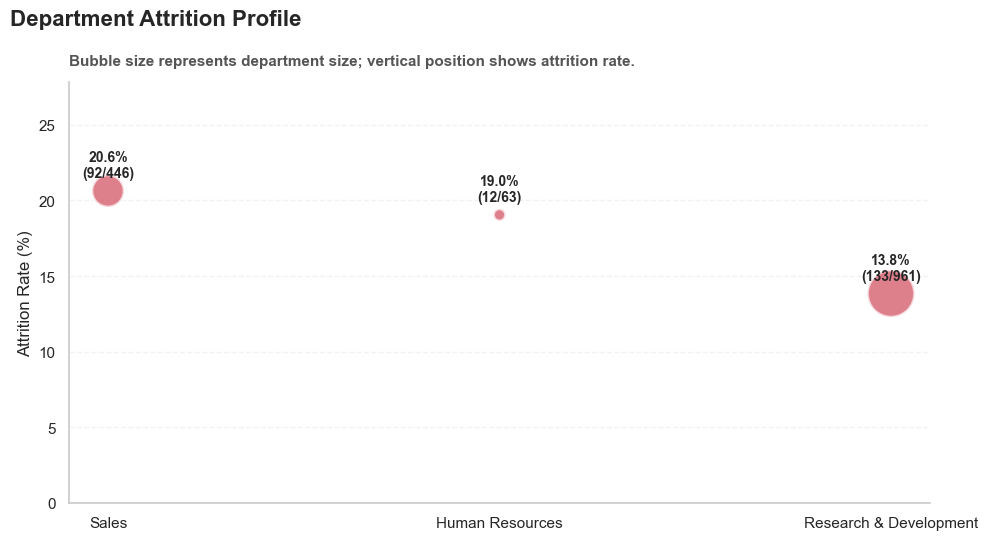

In [ ]:

# Step 14: Department analysis — Attrition rate and department size


# Calculate department-level summary
department_summary = (
    df_clean
    .groupby("Department")
    .agg(
        employees=("Attrition", "size"),
        employees_left=("Attrition", "sum"),
        attrition_rate=("Attrition", "mean")
    )
    .reset_index()
)

# Convert attrition rate to percentage
department_summary["attrition_rate_percent"] = department_summary["attrition_rate"] * 100

# Sort by attrition rate for storytelling
department_summary = department_summary.sort_values(
    "attrition_rate_percent",
    ascending=False
).reset_index(drop=True)

display(department_summary)

# Bubble size shows department size
bubble_size = department_summary["employees"] * 1.2

# Create figure
fig, ax = plt.subplots(figsize=(10, 5.5))

# Bubble chart
ax.scatter(
    x=department_summary["Department"],
    y=department_summary["attrition_rate_percent"],
    s=bubble_size,
    color="#D1495B",
    alpha=0.70,
    edgecolor="white",
    linewidth=2
)

# Add labels above each bubble
for i, row in department_summary.iterrows():
    ax.text(
        x=i,
        y=row["attrition_rate_percent"] + 0.7,
        s=f"{row['attrition_rate_percent']:.1f}%\n({int(row['employees_left'])}/{int(row['employees'])})",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

# Titles
fig.suptitle(
    "Department Attrition Profile",
    fontsize=16,
    fontweight="bold",
    x=0.01,
    ha="left"
)

ax.set_title(
    "Bubble size represents department size; vertical position shows attrition rate.",
    fontsize=11,
    color="#555555",
    loc="left",
    pad=12
)

# Axis formatting
ax.set_xlabel("")
ax.set_ylabel("Attrition Rate (%)")
ax.set_ylim(0, department_summary["attrition_rate_percent"].max() * 1.35)

# Clean formatting
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.25)
ax.grid(axis="x", visible=False)

plt.tight_layout()
plt.show()

<div style="background-color:#111827; color:#ffffff; padding:18px; border-left:6px solid #38bdf8; border-radius:8px;">

<h2>🏢 Conclusion: Department Attrition Profile</h2>

<p>Attrition differs across departments, but it is important to compare both <strong>attrition rate</strong> and <strong>employee count</strong>.</p>

</div>

---

## 📊 Department Attrition Summary

| Department | Employees Who Left | Total Employees | Attrition Rate |
|---|---:|---:|---:|
| Sales | **92** | **446** | **20.6%** |
| Human Resources | **12** | **63** | **19.0%** |
| Research & Development | **133** | **961** | **13.8%** |

<div style="background-color:#111827; color:#ffffff; padding:16px; border-left:6px solid #ef4444; border-radius:8px;">

<h3>🚨 Highest Attrition Rate</h3>

<p><strong>Sales</strong> shows the highest attrition rate at <strong>20.6%</strong>.</p>

<p>In this department, <strong>92 out of 446 employees</strong> left the company.</p>

</div>

---

## 👥 Human Resources Department

Human Resources has an attrition rate of **19.0%**.

However, the department is much smaller, with only **63 employees** in total.

Because of the small department size, this percentage should be interpreted carefully.

<div style="background-color:#111827; color:#ffffff; padding:16px; border-left:6px solid #facc15; border-radius:8px;">

<h3>⚠️ Important Caution</h3>

<p>A high percentage in a small department can look significant, but it may be based on a small number of employees.</p>

<p>Therefore, the Human Resources percentage should be reviewed carefully and not overinterpreted without more context.</p>

</div>

---

## 🔬 Research & Development Department

Research & Development is the largest department, with **961 employees**.

It has a lower attrition rate of **13.8%**.

However, because it is the largest department, it still contributes the highest number of employees who left in absolute count: **133 employees**.

<div style="background-color:#111827; color:#ffffff; padding:16px; border-left:6px solid #f97316; border-radius:8px;">

<h3>📌 Absolute Count Insight</h3>

<p>Research & Development does not have the highest attrition rate, but it has the highest number of employees who left.</p>

<p>This is because it is the largest department in the dataset.</p>

</div>

---

## 🧠 Business Interpretation

This analysis shows why we should look at both:

- **Attrition rate**
- **Employee count**

A department can have a high attrition rate because many people leave proportionally.

At the same time, a larger department can have more total leavers even with a lower attrition percentage.

<div style="background-color:#111827; color:#ffffff; padding:16px; border-left:6px solid #22c55e; border-radius:8px;">

<h3>✅ Final Takeaway</h3>

<p><strong>Sales</strong> should be monitored because it has the highest attrition rate.</p>

<p><strong>Research & Development</strong> should also be monitored because it contributes the highest number of employees who left.</p>

<p>For HR decisions, both percentage-based risk and absolute employee impact should be considered.</p>

</div>


,JobRole,employees,employees_left,attrition_rate,attrition_rate_percent
0,Research Director,80,2,0.025,2.500
1,Manager,102,5,0.049,4.902
2,Healthcare Representative,131,9,0.069,6.870
3,Manufacturing Director,145,10,0.069,6.897
4,Research Scientist,292,47,0.161,16.096
5,Sales Executive,326,57,0.175,17.485
6,Human Resources,52,12,0.231,23.077
7,Laboratory Technician,259,62,0.239,23.938
8,Sales Representative,83,33,0.398,39.759


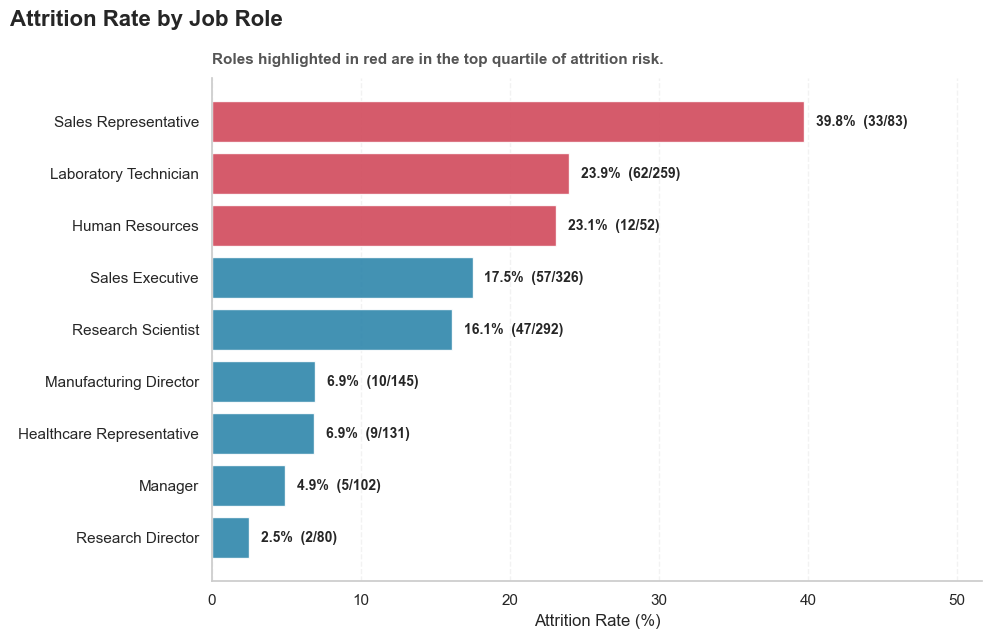

In [25]:

# Step 15: Attrition rate by Job Role


# Calculate job-role-level summary
jobrole_summary = (
    df_clean
    .groupby("JobRole")
    .agg(
        employees=("Attrition", "size"),
        employees_left=("Attrition", "sum"),
        attrition_rate=("Attrition", "mean")
    )
    .reset_index()
)

# Convert attrition rate to percentage
jobrole_summary["attrition_rate_percent"] = jobrole_summary["attrition_rate"] * 100

# Sort by attrition rate
jobrole_summary = jobrole_summary.sort_values(
    "attrition_rate_percent",
    ascending=True
).reset_index(drop=True)

display(jobrole_summary)

# Create figure
fig, ax = plt.subplots(figsize=(10, 6.5))

# Color highest-risk roles differently
colors = [
    "#D1495B" if rate >= jobrole_summary["attrition_rate_percent"].quantile(0.75)
    else "#2E86AB"
    for rate in jobrole_summary["attrition_rate_percent"]
]

bars = ax.barh(
    jobrole_summary["JobRole"],
    jobrole_summary["attrition_rate_percent"],
    color=colors,
    alpha=0.90
)

# Add labels
for bar, rate, left_count, total_count in zip(
    bars,
    jobrole_summary["attrition_rate_percent"],
    jobrole_summary["employees_left"],
    jobrole_summary["employees"]
):
    ax.text(
        bar.get_width() + 0.8,
        bar.get_y() + bar.get_height() / 2,
        f"{rate:.1f}%  ({int(left_count)}/{int(total_count)})",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

# Titles
fig.suptitle(
    "Attrition Rate by Job Role",
    fontsize=16,
    fontweight="bold",
    x=0.01,
    ha="left"
)

ax.set_title(
    "Roles highlighted in red are in the top quartile of attrition risk.",
    fontsize=11,
    color="#555555",
    loc="left",
    pad=10
)

# Formatting
ax.set_xlabel("Attrition Rate (%)")
ax.set_ylabel("")
ax.set_xlim(0, jobrole_summary["attrition_rate_percent"].max() * 1.30)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="x", linestyle="--", alpha=0.25)
ax.grid(axis="y", visible=False)

plt.tight_layout()
plt.show()

<div style="background-color:#111827; color:#ffffff; padding:18px; border-left:6px solid #38bdf8; border-radius:8px;">

<h2>💼 Conclusion: Attrition Rate by Job Role</h2>

<p>Attrition risk differs strongly across job roles.</p>

<p>The highest-risk role is <strong>Sales Representative</strong>.</p>

</div>

---

## 📊 Job Role Attrition Summary

| Job Role | Employees Who Left | Total Employees | Attrition Rate |
|---|---:|---:|---:|
| Sales Representative | **33** | **83** | **39.8%** |
| Laboratory Technician | — | — | **23.9%** |
| Human Resources | — | — | **23.1%** |
| Overall Company | **237** | **1,470** | **16.12%** |

<div style="background-color:#111827; color:#ffffff; padding:16px; border-left:6px solid #ef4444; border-radius:8px;">

<h3>🚨 Highest-Risk Job Role</h3>

<p><strong>Sales Representative</strong> has the highest attrition rate at <strong>39.8%</strong>.</p>

<p>In this role, <strong>33 out of 83 employees</strong> left the company.</p>

<p>This is much higher than the overall company attrition rate of <strong>16.12%</strong>.</p>

</div>

---

## ⚠️ Other High-Risk Roles

Other roles with high attrition rates include:

- **Laboratory Technician**: **23.9%**
- **Human Resources**: **23.1%**

These roles also show attrition rates above the overall company average.

---

## 🧠 Business Interpretation

This suggests that **job role is an important factor** for understanding employee attrition.

Some roles may have higher attrition because of:

- Higher workload
- More pressure
- Limited growth opportunities
- Compensation-related issues
- Lower job satisfaction
- Higher overtime exposure

<div style="background-color:#111827; color:#ffffff; padding:16px; border-left:6px solid #f97316; border-radius:8px;">

<h3>📌 Interpretation Note</h3>

<p>Job role appears to be strongly associated with attrition risk.</p>

<p>However, role-level attrition should be combined with other variables before making business decisions.</p>

</div>

---

## 🔗 Variables to Combine Later

This finding should later be analyzed together with:

- **Overtime**
- **Monthly income**
- **Department**
- **Job satisfaction**
- **Work-life balance**
- **Years at company**

<div style="background-color:#111827; color:#ffffff; padding:16px; border-left:6px solid #facc15; border-radius:8px;">

<h3>⚠️ Important Caution</h3>

<p><strong>Sales Representative</strong> has only <strong>83 employees</strong>.</p>

<p>Therefore, the percentage is high, but the group is smaller than roles such as <strong>Sales Executive</strong> or <strong>Research Scientist</strong>.</p>

<p>This result should be interpreted carefully and not treated as proof that job role alone causes attrition.</p>

</div>

---

## ✅ Final Takeaway

`JobRole` is an important variable for understanding employee attrition.

The **Sales Representative** role should be reviewed closely because it shows the highest attrition rate, but the result should be interpreted together with employee count and other influencing factors.


,Attrition Status,employees,mean,median,q1,q3,minimum,maximum
0,Stayed,1233,6832.740,5204.000,3211.000,8834.000,1051,19999
1,Left,237,4787.093,3202.000,2373.000,5916.000,1009,19859


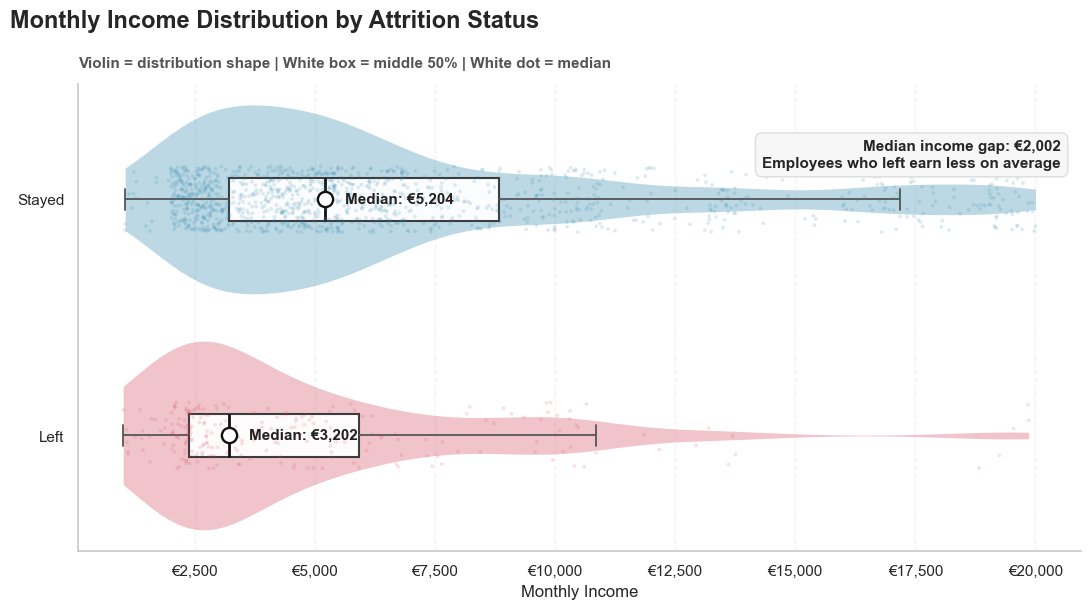

In [29]:

# Step 16: Monthly Income by Attrition Status
# version: Violin + Box + Median


from matplotlib.ticker import FuncFormatter

# Create readable labels
income_plot_data = df_clean.copy()
income_plot_data["Attrition Status"] = income_plot_data["Attrition"].map({
    0: "Stayed",
    1: "Left"
})

order = ["Stayed", "Left"]

# Summary table
income_summary = (
    income_plot_data
    .groupby("Attrition Status")["MonthlyIncome"]
    .agg(
        employees="count",
        mean="mean",
        median="median",
        q1=lambda x: x.quantile(0.25),
        q3=lambda x: x.quantile(0.75),
        minimum="min",
        maximum="max"
    )
    .reindex(order)
    .reset_index()
)

display(income_summary)

# Key numbers
median_stayed = income_summary.loc[
    income_summary["Attrition Status"] == "Stayed", "median"
].iloc[0]

median_left = income_summary.loc[
    income_summary["Attrition Status"] == "Left", "median"
].iloc[0]

median_gap = median_stayed - median_left

# Colors
palette = {
    "Stayed": "#2E86AB",
    "Left": "#D1495B"
}

# Figure
fig, ax = plt.subplots(figsize=(11, 6.2))

# 1) Violin plot = full distribution shape
sns.violinplot(
    data=income_plot_data,
    y="Attrition Status",
    x="MonthlyIncome",
    order=order,
    palette=palette,
    inner=None,
    cut=0,
    linewidth=0,
    saturation=1,
    ax=ax
)

# Make violin slightly transparent
for collection in ax.collections:
    try:
        collection.set_alpha(0.32)
    except:
        pass

# 2) Boxplot = middle 50% of employees
sns.boxplot(
    data=income_plot_data,
    y="Attrition Status",
    x="MonthlyIncome",
    order=order,
    width=0.18,
    showfliers=False,
    boxprops={
        "facecolor": "white",
        "edgecolor": "#333333",
        "linewidth": 1.5,
        "alpha": 0.95
    },
    medianprops={
        "color": "#111111",
        "linewidth": 2
    },
    whiskerprops={
        "color": "#555555",
        "linewidth": 1.3
    },
    capprops={
        "color": "#555555",
        "linewidth": 1.3
    },
    ax=ax
)

# 3) Small dots = individual employees
sns.stripplot(
    data=income_plot_data,
    y="Attrition Status",
    x="MonthlyIncome",
    order=order,
    hue="Attrition Status",
    palette=palette,
    dodge=False,
    jitter=0.14,
    size=2.7,
    alpha=0.16,
    linewidth=0,
    ax=ax
)

# Remove extra legend
if ax.get_legend() is not None:
    ax.get_legend().remove()

# 4) Highlight median with white dot + label
for i, row in income_summary.iterrows():
    ax.scatter(
        row["median"],
        i,
        s=120,
        color="white",
        edgecolor="#111111",
        linewidth=1.7,
        zorder=6
    )
    
    ax.text(
        row["median"] + 420,
        i,
        f"Median: €{row['median']:,.0f}",
        va="center",
        ha="left",
        fontsize=11,
        fontweight="bold",
        color="#222222"
    )

# Main insight box
ax.text(
    0.98,
    0.88,
    f"Median income gap: €{median_gap:,.0f}\nEmployees who left earn less on average",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=11,
    fontweight="bold",
    bbox=dict(
        boxstyle="round,pad=0.45",
        facecolor="#F7F7F7",
        edgecolor="#DDDDDD"
    )
)

# Titles
fig.suptitle(
    "Monthly Income Distribution by Attrition Status",
    fontsize=17,
    fontweight="bold",
    x=0.01,
    ha="left"
)

ax.set_title(
    "Violin = distribution shape | White box = middle 50% | White dot = median",
    fontsize=11,
    color="#555555",
    loc="left",
    pad=12
)

# Axis formatting
ax.set_xlabel("Monthly Income")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"€{x:,.0f}"))

# Clean style
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="x", linestyle="--", alpha=0.22)
ax.grid(axis="y", visible=False)

plt.tight_layout()
plt.show()

<div style="background-color:#111827; color:#ffffff; padding:18px; border-left:6px solid #22c55e; border-radius:8px;">

<h2>💰 Conclusion: Monthly Income by Attrition Status</h2>

<p>Employees who left the company generally had <strong>lower monthly income</strong> than employees who stayed.</p>

</div>

---

## 📊 Median Monthly Income Summary

| Attrition Status | Median Monthly Income |
|---|---:|
| Stayed | **€5,204** |
| Left | **€3,202** |
| Median income gap | **€2,002** |

<div style="background-color:#111827; color:#ffffff; padding:16px; border-left:6px solid #f97316; border-radius:8px;">

<h3>📌 Key Income Gap Insight</h3>

<p>The median monthly income for employees who stayed is <strong>€5,204</strong>.</p>

<p>The median monthly income for employees who left is <strong>€3,202</strong>.</p>

<p>This creates a median income gap of approximately <strong>€2,002</strong>.</p>

</div>

---

## 🎻 Distribution Interpretation

The violin plot shows that employees who stayed have a **wider income distribution** and include more higher-income employees.

Employees who left are more concentrated in the **lower-income range**.

<div style="background-color:#111827; color:#ffffff; padding:16px; border-left:6px solid #ef4444; border-radius:8px;">

<h3>🚨 Important Pattern</h3>

<p>Employees who left are more concentrated in lower monthly income ranges.</p>

<p>This suggests that <strong>MonthlyIncome</strong> may be an important variable for predicting employee attrition.</p>

</div>

---

## 🧠 Business Interpretation

This finding suggests that monthly income may be associated with employee attrition.

Employees with lower income may have:

- Lower financial satisfaction
- Fewer perceived rewards
- Higher sensitivity to external job offers
- Lower attachment to the company
- Fewer career progression signals

<div style="background-color:#111827; color:#ffffff; padding:16px; border-left:6px solid #facc15; border-radius:8px;">

<h3>⚠️ Important Caution</h3>

<p>This should be interpreted as an <strong>association</strong>, not proof that income alone causes employees to leave.</p>

<p>Other factors may also influence attrition, such as job role, job level, overtime, department, satisfaction, and career growth.</p>

</div>

---

## ✅ Final Takeaway

`MonthlyIncome` appears to be an important variable for understanding employee attrition.

Employees who left had a noticeably lower median monthly income, but this finding should be interpreted together with role, level, satisfaction, overtime, and career growth factors.


<div style="background-color:#111827; color:#ffffff; padding:18px; border-left:6px solid #8b5cf6; border-radius:8px;">

<h2>📖 How to Read This Chart</h2>

<p>This chart combines a <strong>violin plot</strong>, a <strong>boxplot</strong>, and individual employee data points to compare monthly income by attrition status.</p>

</div>

---

## 🎻 Violin Plot

A **violin plot** shows the shape of the distribution.

Wider parts mean more employees are concentrated in that income range.

---

## 📦 Boxplot

A **boxplot** summarizes the middle part of the data.

The white box represents the middle **50%** of employees, and the line or dot inside the box shows the **median**.

---

## 📍 Median and Individual Employees

The **median** is the middle value when all salaries are sorted from lowest to highest.

It is useful because it is less affected by very high salaries.

The small dots represent individual employees.


,AgeBand,employees,employees_left,attrition_rate,attrition_rate_percent
0,18–25,123,44,0.358,35.772
1,26–30,263,56,0.213,21.293
2,31–35,343,60,0.175,17.493
3,36–40,276,25,0.091,9.058
4,41–45,192,18,0.094,9.375
5,46–50,130,16,0.123,12.308
6,51–60,143,18,0.126,12.587


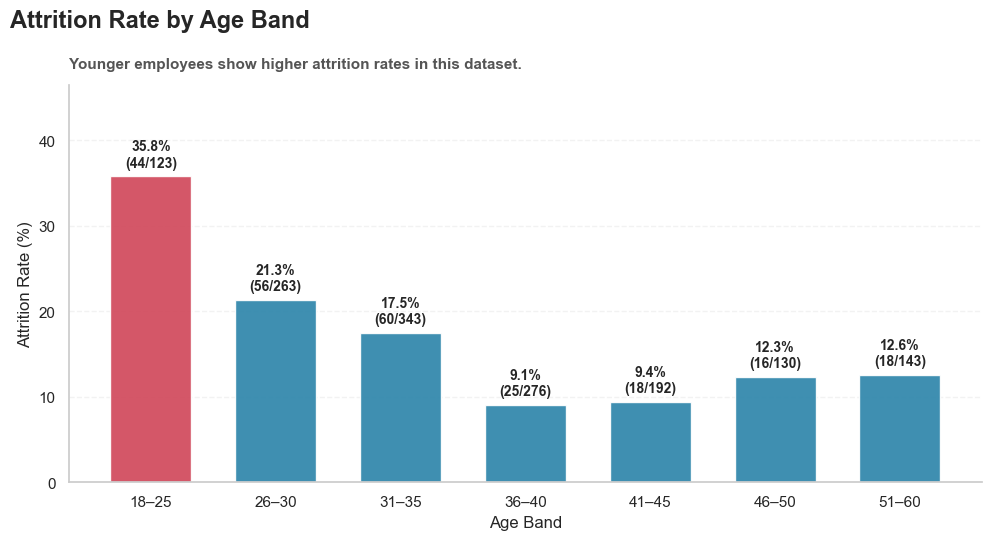

In [30]:
# Step 17: Attrition rate by Age Band


# Create a working copy for age analysis
age_band_data = df_clean.copy()

# Create age bands
age_bins = [17, 25, 30, 35, 40, 45, 50, 60]
age_labels = ["18–25", "26–30", "31–35", "36–40", "41–45", "46–50", "51–60"]

age_band_data["AgeBand"] = pd.cut(
    age_band_data["Age"],
    bins=age_bins,
    labels=age_labels
)

# Calculate attrition summary by age band
age_band_summary = (
    age_band_data
    .groupby("AgeBand", observed=True)
    .agg(
        employees=("Attrition", "size"),
        employees_left=("Attrition", "sum"),
        attrition_rate=("Attrition", "mean")
    )
    .reset_index()
)

# Convert to percentage
age_band_summary["attrition_rate_percent"] = age_band_summary["attrition_rate"] * 100

display(age_band_summary)

# Create figure
fig, ax = plt.subplots(figsize=(10, 5.5))

# Color highest attrition band differently
max_rate = age_band_summary["attrition_rate_percent"].max()

colors = [
    "#D1495B" if rate == max_rate else "#2E86AB"
    for rate in age_band_summary["attrition_rate_percent"]
]

# Bar chart
bars = ax.bar(
    age_band_summary["AgeBand"].astype(str),
    age_band_summary["attrition_rate_percent"],
    color=colors,
    width=0.65,
    alpha=0.92
)

# Add labels above bars
for bar, rate, left_count, total_count in zip(
    bars,
    age_band_summary["attrition_rate_percent"],
    age_band_summary["employees_left"],
    age_band_summary["employees"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.8,
        f"{rate:.1f}%\n({int(left_count)}/{int(total_count)})",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

# Titles
fig.suptitle(
    "Attrition Rate by Age Band",
    fontsize=17,
    fontweight="bold",
    x=0.01,
    ha="left"
)

ax.set_title(
    "Younger employees show higher attrition rates in this dataset.",
    fontsize=11,
    color="#555555",
    loc="left",
    pad=12
)

# Axis formatting
ax.set_xlabel("Age Band")
ax.set_ylabel("Attrition Rate (%)")

ax.set_ylim(0, age_band_summary["attrition_rate_percent"].max() * 1.30)

# Clean style
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.25)
ax.grid(axis="x", visible=False)

plt.tight_layout()
plt.show()

<div style="background-color:#111827; color:#ffffff; padding:18px; border-left:6px solid #38bdf8; border-radius:8px;">

<h2>🎂 Conclusion: Attrition Rate by Age Band</h2>

<p>The age-band analysis shows that <strong>younger employees have higher attrition rates</strong>.</p>

</div>

---

## 📊 Attrition Summary by Age Band

| Age Band | Employees Who Left | Total Employees | Attrition Rate |
|---|---:|---:|---:|
| 18–25 | **44** | **123** | **35.8%** |
| 26–30 | — | — | **21.3%** |
| 31–35 | — | — | **17.5%** |
| Above 35 | — | — | Lower attrition |

<div style="background-color:#111827; color:#ffffff; padding:16px; border-left:6px solid #ef4444; border-radius:8px;">

<h3>🚨 Highest-Risk Age Group</h3>

<p>The highest attrition rate is in the <strong>18–25</strong> age group.</p>

<p>In this group, <strong>44 out of 123 employees</strong> left the company.</p>

<p>This gives an attrition rate of <strong>35.8%</strong>.</p>

</div>

---

## 📉 Age-Related Attrition Pattern

The attrition rate decreases in the older age bands:

- Employees aged **26–30** have an attrition rate of **21.3%**
- Employees aged **31–35** have an attrition rate of **17.5%**
- After age **35**, the attrition rate is much lower

<div style="background-color:#111827; color:#ffffff; padding:16px; border-left:6px solid #f97316; border-radius:8px;">

<h3>📌 Key Pattern</h3>

<p>Attrition risk is highest among the youngest employees and becomes lower after age 35.</p>

<p>This suggests that <strong>Age</strong> may be an important variable for predicting employee attrition.</p>

</div>

---

## 🧠 Business Interpretation

Younger employees may be more likely to leave because they may:

- Explore new career opportunities
- Change roles more frequently
- Compare salary and growth options externally
- Have different expectations around work-life balance
- Leave if career development expectations are not met

<div style="background-color:#111827; color:#ffffff; padding:16px; border-left:6px solid #facc15; border-radius:8px;">

<h3>⚠️ Important Caution</h3>

<p>This should be interpreted as an <strong>association</strong>, not direct proof that age alone causes attrition.</p>

<p>Other factors such as salary, job role, overtime, career growth, satisfaction, and work-life balance may also influence attrition.</p>

</div>

---

## ✅ Final Takeaway

`Age` appears to be an important attrition-related variable.

Younger employees, especially those aged **18–25**, should be reviewed carefully for possible issues related to onboarding, salary expectations, career growth, and work-life balance.


,YearsAtCompanyBand,employees,employees_left,attrition_rate,attrition_rate_percent
0,0–1,215,75,0.349,34.884
1,2–3,255,47,0.184,18.431
2,4–5,306,40,0.131,13.072
3,6–10,448,55,0.123,12.277
4,11–20,180,12,0.067,6.667
5,21+,66,8,0.121,12.121


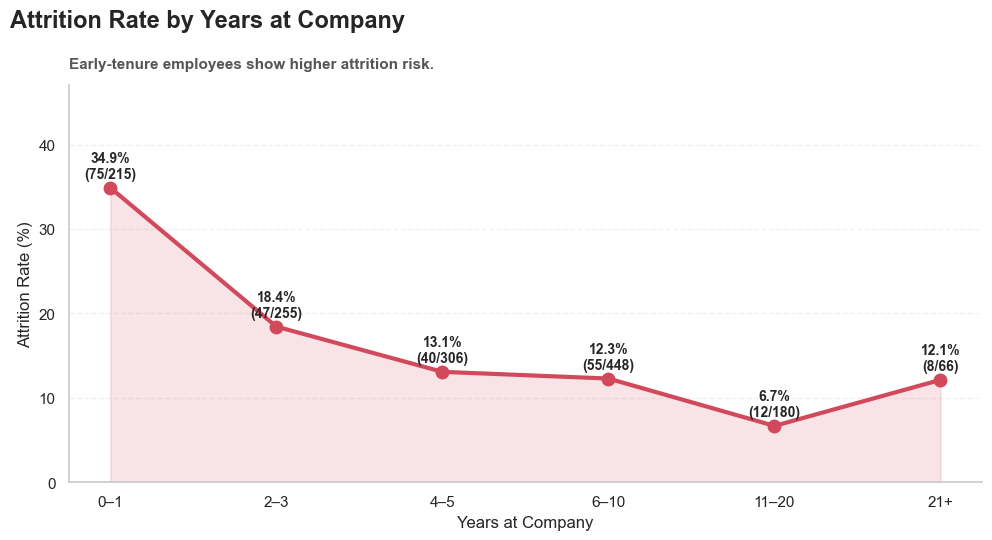

In [31]:
# Step 18: Attrition rate by Years at Company band


# Create a working copy
tenure_data = df_clean.copy()

# Create tenure bands
tenure_bins = [-1, 1, 3, 5, 10, 20, 40]
tenure_labels = ["0–1", "2–3", "4–5", "6–10", "11–20", "21+"]

tenure_data["YearsAtCompanyBand"] = pd.cut(
    tenure_data["YearsAtCompany"],
    bins=tenure_bins,
    labels=tenure_labels
)

# Calculate attrition summary by tenure band
tenure_summary = (
    tenure_data
    .groupby("YearsAtCompanyBand", observed=True)
    .agg(
        employees=("Attrition", "size"),
        employees_left=("Attrition", "sum"),
        attrition_rate=("Attrition", "mean")
    )
    .reset_index()
)

# Convert attrition rate to percentage
tenure_summary["attrition_rate_percent"] = tenure_summary["attrition_rate"] * 100

display(tenure_summary)

# Create figure
fig, ax = plt.subplots(figsize=(10, 5.5))

# Line chart
ax.plot(
    tenure_summary["YearsAtCompanyBand"].astype(str),
    tenure_summary["attrition_rate_percent"],
    color="#D1495B",
    marker="o",
    linewidth=3,
    markersize=9
)

# Fill area under line
ax.fill_between(
    tenure_summary["YearsAtCompanyBand"].astype(str),
    tenure_summary["attrition_rate_percent"],
    color="#D1495B",
    alpha=0.15
)

# Add labels for each point
for x, rate, left_count, total_count in zip(
    tenure_summary["YearsAtCompanyBand"].astype(str),
    tenure_summary["attrition_rate_percent"],
    tenure_summary["employees_left"],
    tenure_summary["employees"]
):
    ax.text(
        x,
        rate + 0.8,
        f"{rate:.1f}%\n({int(left_count)}/{int(total_count)})",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

# Titles
fig.suptitle(
    "Attrition Rate by Years at Company",
    fontsize=17,
    fontweight="bold",
    x=0.01,
    ha="left"
)

ax.set_title(
    "Early-tenure employees show higher attrition risk.",
    fontsize=11,
    color="#555555",
    loc="left",
    pad=12
)

# Axis formatting
ax.set_xlabel("Years at Company")
ax.set_ylabel("Attrition Rate (%)")

ax.set_ylim(0, tenure_summary["attrition_rate_percent"].max() * 1.35)

# Clean style
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.25)
ax.grid(axis="x", visible=False)

plt.tight_layout()
plt.show()

<div style="background-color:#111827; color:#ffffff; padding:18px; border-left:6px solid #38bdf8; border-radius:8px;">

<h2>⏳ Conclusion: Attrition Rate by Years at Company</h2>

<p>Employees with <strong>shorter tenure</strong> show a much higher attrition rate.</p>

<p>This suggests that early-tenure employees are at greater risk of leaving.</p>

</div>

---

## 📊 Attrition Summary by Years at Company

| Years at Company | Employees Who Left | Total Employees | Attrition Rate |
|---|---:|---:|---:|
| 0–1 years | **75** | **215** | **34.9%** |
| 2–3 years | — | — | **18.4%** |
| 4–5 years | — | — | **13.1%** |
| 21+ years | — | **66** | **12.1%** |

<div style="background-color:#111827; color:#ffffff; padding:16px; border-left:6px solid #ef4444; border-radius:8px;">

<h3>🚨 Highest-Risk Tenure Group</h3>

<p>The highest attrition rate is in the <strong>0–1 years</strong> group.</p>

<p>In this group, <strong>75 out of 215 employees</strong> left the company.</p>

<p>This gives an attrition rate of <strong>34.9%</strong>.</p>

</div>

---

## 📉 Tenure-Related Attrition Pattern

After the first few years, attrition decreases clearly.

- Employees with **2–3 years** at the company have an attrition rate of **18.4%**
- Employees with **4–5 years** at the company have an attrition rate of **13.1%**

<div style="background-color:#111827; color:#ffffff; padding:16px; border-left:6px solid #f97316; border-radius:8px;">

<h3>📌 Key Pattern</h3>

<p>Attrition risk is highest during the first year of employment.</p>

<p>After employees stay beyond the early-tenure period, the likelihood of leaving decreases clearly.</p>

</div>

---

## 🧠 Business Interpretation

This suggests that early-tenure employees are at higher risk of leaving.

Possible reasons could include:

- Weak onboarding experience
- Mismatch between job expectations and reality
- Early career exploration
- Limited perceived growth opportunities
- Lack of connection with the company
- Poor early manager support

<div style="background-color:#111827; color:#ffffff; padding:16px; border-left:6px solid #facc15; border-radius:8px;">

<h3>⚠️ Important Caution</h3>

<p>The <strong>21+ years</strong> group shows a slight increase in attrition rate to <strong>12.1%</strong>.</p>

<p>However, this group is small, with only <strong>66 employees</strong>.</p>

<p>Therefore, this percentage should be interpreted carefully and not overgeneralized.</p>

</div>

---

## ✅ Final Takeaway

`YearsAtCompany` appears to be an important variable for understanding and predicting employee attrition.

The biggest business focus should be on employees in their **first year**, because this group shows the highest attrition risk.


,JobSatisfaction,employees,employees_left,attrition_rate,attrition_rate_percent
0,1,289,66,0.228,22.837
1,2,280,46,0.164,16.429
2,3,442,73,0.165,16.516
3,4,459,52,0.113,11.329


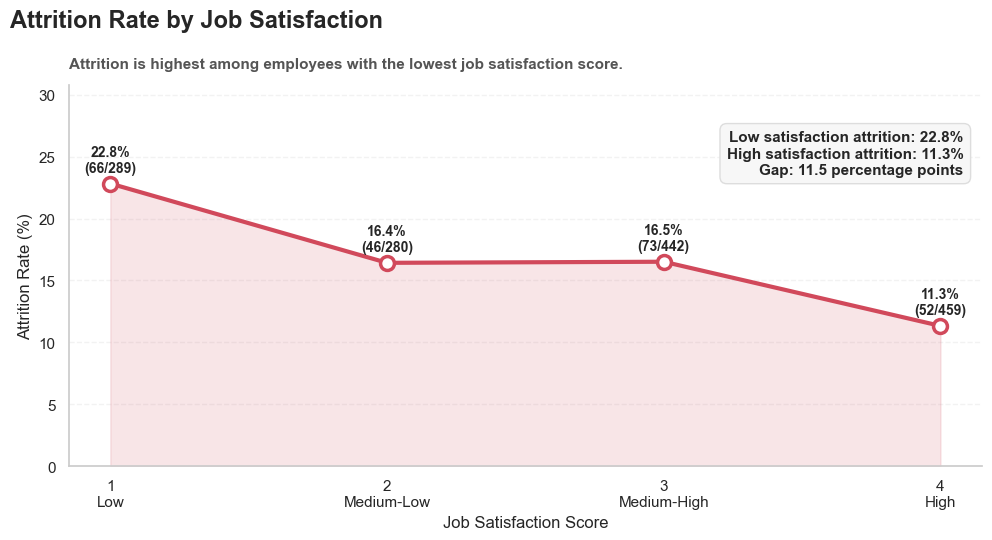

In [33]:
# Step 19: Attrition rate by Job Satisfaction



# Create summary by JobSatisfaction score
satisfaction_summary = (
    df_clean
    .groupby("JobSatisfaction")
    .agg(
        employees=("Attrition", "size"),
        employees_left=("Attrition", "sum"),
        attrition_rate=("Attrition", "mean")
    )
    .reset_index()
)

# Convert attrition rate to percentage
satisfaction_summary["attrition_rate_percent"] = satisfaction_summary["attrition_rate"] * 100

display(satisfaction_summary)

# Create readable labels for x-axis
satisfaction_labels = {
    1: "1\nLow",
    2: "2\nMedium-Low",
    3: "3\nMedium-High",
    4: "4\nHigh"
}

satisfaction_summary["label"] = satisfaction_summary["JobSatisfaction"].map(satisfaction_labels)

# Create figure
fig, ax = plt.subplots(figsize=(10, 5.5))

# Soft area under line
ax.fill_between(
    satisfaction_summary["JobSatisfaction"],
    satisfaction_summary["attrition_rate_percent"],
    color="#D1495B",
    alpha=0.14
)

# Trend line
ax.plot(
    satisfaction_summary["JobSatisfaction"],
    satisfaction_summary["attrition_rate_percent"],
    color="#D1495B",
    linewidth=3,
    marker="o",
    markersize=10,
    markerfacecolor="white",
    markeredgecolor="#D1495B",
    markeredgewidth=2.5
)

# Add labels for each point
for _, row in satisfaction_summary.iterrows():
    ax.text(
        row["JobSatisfaction"],
        row["attrition_rate_percent"] + 0.7,
        f"{row['attrition_rate_percent']:.1f}%\n({int(row['employees_left'])}/{int(row['employees'])})",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

# Highlight lowest and highest satisfaction
lowest_rate = satisfaction_summary.loc[
    satisfaction_summary["JobSatisfaction"] == 1,
    "attrition_rate_percent"
].iloc[0]

highest_rate = satisfaction_summary.loc[
    satisfaction_summary["JobSatisfaction"] == 4,
    "attrition_rate_percent"
].iloc[0]

gap = lowest_rate - highest_rate

# Insight box
ax.text(
    0.98,
    0.88,
    f"Low satisfaction attrition: {lowest_rate:.1f}%\n"
    f"High satisfaction attrition: {highest_rate:.1f}%\n"
    f"Gap: {gap:.1f} percentage points",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=11,
    fontweight="bold",
    bbox=dict(
        boxstyle="round,pad=0.45",
        facecolor="#F7F7F7",
        edgecolor="#DDDDDD"
    )
)

# Titles
fig.suptitle(
    "Attrition Rate by Job Satisfaction",
    fontsize=17,
    fontweight="bold",
    x=0.01,
    ha="left"
)

ax.set_title(
    "Attrition is highest among employees with the lowest job satisfaction score.",
    fontsize=11,
    color="#555555",
    loc="left",
    pad=12
)

# Axis formatting
ax.set_xlabel("Job Satisfaction Score")
ax.set_ylabel("Attrition Rate (%)")

ax.set_xticks(satisfaction_summary["JobSatisfaction"])
ax.set_xticklabels(satisfaction_summary["label"])

ax.set_ylim(0, satisfaction_summary["attrition_rate_percent"].max() * 1.35)

# Clean style
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.25)
ax.grid(axis="x", visible=False)

plt.tight_layout()
plt.show()

<div style="background-color:#111827; color:#ffffff; padding:18px; border-left:6px solid #38bdf8; border-radius:8px;">

<h2>😊 Conclusion: Job Satisfaction and Attrition</h2>

<p>Employees with the <strong>lowest job satisfaction score</strong> show the highest attrition rate.</p>

<p>This suggests that job satisfaction is an important attrition-related signal.</p>

</div>

---

## 📊 Attrition Rate by Job Satisfaction

| Job Satisfaction Score | Attrition Rate |
|---|---:|
| 1 — Low | **22.8%** |
| 4 — High | **11.3%** |
| Difference | **11.5 percentage points** |

<div style="background-color:#111827; color:#ffffff; padding:16px; border-left:6px solid #ef4444; border-radius:8px;">

<h3>🚨 Key Insight</h3>

<p>Employees with a job satisfaction score of <strong>1</strong> have an attrition rate of <strong>22.8%</strong>.</p>

<p>Employees with the highest satisfaction score of <strong>4</strong> have an attrition rate of only <strong>11.3%</strong>.</p>

<p>This creates a gap of <strong>11.5 percentage points</strong>.</p>

</div>

---

## 🧠 Business Interpretation

This suggests that **job satisfaction is related to employee attrition**.

Employees who are less satisfied with their job appear more likely to leave the company.

Possible reasons may include:

- Lower motivation
- Poorer employee experience
- Frustration with role expectations
- Weak relationship with manager or team
- Limited growth or recognition

---

## 📌 Pattern Interpretation

The pattern is **not perfectly linear**, because satisfaction scores **2** and **3** have very similar attrition rates.

Therefore, the strongest business takeaway is:

<div style="background-color:#111827; color:#ffffff; padding:16px; border-left:6px solid #f97316; border-radius:8px;">

<h3>📌 Main Business Takeaway</h3>

<p><strong>Very low job satisfaction is a warning signal.</strong></p>

<p>High job satisfaction is associated with lower attrition.</p>

</div>

---

<div style="background-color:#111827; color:#ffffff; padding:16px; border-left:6px solid #facc15; border-radius:8px;">

<h3>⚠️ Important Caution</h3>

<p>This should be interpreted as an <strong>association</strong>, not direct proof that job satisfaction alone causes attrition.</p>

<p>Other variables such as overtime, income, job role, department, work-life balance, and career growth may also influence attrition.</p>

</div>

---

## ✅ Final Takeaway

`JobSatisfaction` appears to be an important variable for understanding employee attrition.

The clearest HR signal is that employees with **very low job satisfaction** should be monitored carefully and supported early.


,WorkLifeBalance,employees,employees_left,attrition_rate,attrition_rate_percent,label
0,1,80,25,0.312,31.250,Poor
1,2,344,58,0.169,16.860,Fair
2,3,893,127,0.142,14.222,Good
3,4,153,27,0.176,17.647,Excellent


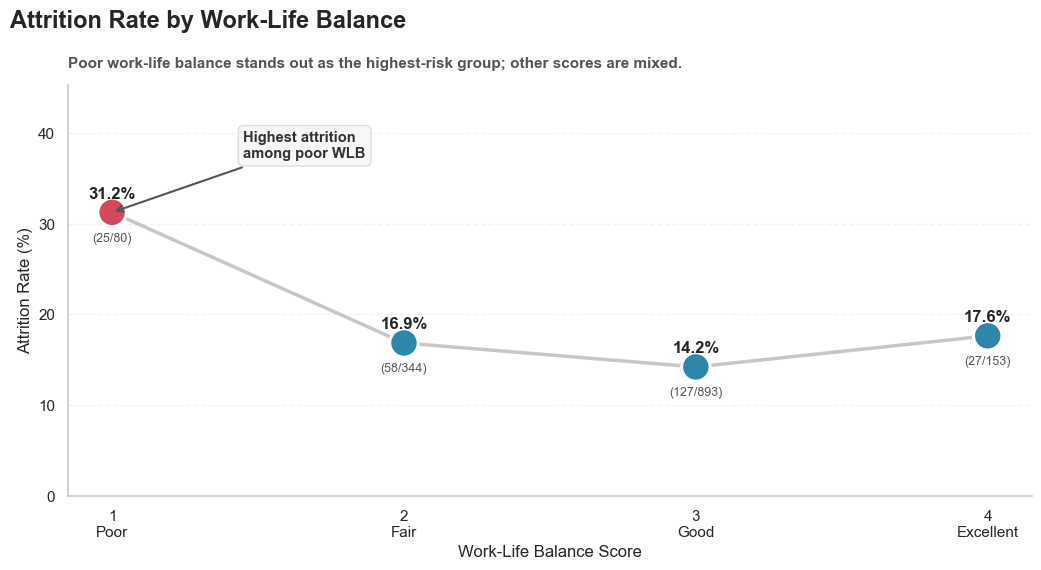

In [35]:
# Step 20: Attrition rate by Work-Life Balance



# Create summary by WorkLifeBalance score
wlb_summary = (
    df_clean
    .groupby("WorkLifeBalance")
    .agg(
        employees=("Attrition", "size"),
        employees_left=("Attrition", "sum"),
        attrition_rate=("Attrition", "mean")
    )
    .reset_index()
)

# Convert to percentage
wlb_summary["attrition_rate_percent"] = wlb_summary["attrition_rate"] * 100

# Add readable labels
wlb_labels = {
    1: "Poor",
    2: "Fair",
    3: "Good",
    4: "Excellent"
}

wlb_summary["label"] = wlb_summary["WorkLifeBalance"].map(wlb_labels)

# Sort naturally from 1 to 4
wlb_summary = wlb_summary.sort_values("WorkLifeBalance").reset_index(drop=True)

display(wlb_summary)

# Key numbers
poor_rate = wlb_summary.loc[
    wlb_summary["WorkLifeBalance"] == 1,
    "attrition_rate_percent"
].iloc[0]

good_rate = wlb_summary.loc[
    wlb_summary["WorkLifeBalance"] == 3,
    "attrition_rate_percent"
].iloc[0]

excellent_rate = wlb_summary.loc[
    wlb_summary["WorkLifeBalance"] == 4,
    "attrition_rate_percent"
].iloc[0]

# Create figure
fig, ax = plt.subplots(figsize=(10.5, 5.8))

# X and Y
x = wlb_summary["WorkLifeBalance"]
y = wlb_summary["attrition_rate_percent"]

# Soft connecting line
ax.plot(
    x,
    y,
    color="#9A9A9A",
    linewidth=2.5,
    alpha=0.55,
    zorder=1
)

# Points
colors = [
    "#D1495B" if score == 1 else "#2E86AB"
    for score in wlb_summary["WorkLifeBalance"]
]

ax.scatter(
    x,
    y,
    s=420,
    color=colors,
    edgecolor="white",
    linewidth=2.2,
    zorder=3
)

# Add labels near points
for _, row in wlb_summary.iterrows():
    ax.text(
        row["WorkLifeBalance"],
        row["attrition_rate_percent"] + 1.2,
        f"{row['attrition_rate_percent']:.1f}%",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold"
    )
    
    ax.text(
        row["WorkLifeBalance"],
        row["attrition_rate_percent"] - 2.2,
        f"({int(row['employees_left'])}/{int(row['employees'])})",
        ha="center",
        va="top",
        fontsize=9,
        color="#555555"
    )

# Insight annotation
ax.annotate(
    "Highest attrition\namong poor WLB",
    xy=(1, poor_rate),
    xytext=(1.45, poor_rate + 6),
    arrowprops=dict(
        arrowstyle="->",
        color="#555555",
        lw=1.5
    ),
    fontsize=10.5,
    fontweight="bold",
    color="#333333",
    bbox=dict(
        boxstyle="round,pad=0.35",
        facecolor="#F7F7F7",
        edgecolor="#DDDDDD"
    )
)

# Title and subtitle
fig.suptitle(
    "Attrition Rate by Work-Life Balance",
    fontsize=17,
    fontweight="bold",
    x=0.01,
    ha="left"
)

ax.set_title(
    "Poor work-life balance stands out as the highest-risk group; other scores are mixed.",
    fontsize=11,
    color="#555555",
    loc="left",
    pad=12
)

# Axis formatting
ax.set_xlabel("Work-Life Balance Score")
ax.set_ylabel("Attrition Rate (%)")

ax.set_xticks(wlb_summary["WorkLifeBalance"])
ax.set_xticklabels(
    [
        "1\nPoor",
        "2\nFair",
        "3\nGood",
        "4\nExcellent"
    ]
)

ax.set_ylim(0, max(y) * 1.45)

# Clean style
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.25)
ax.grid(axis="x", visible=False)

plt.tight_layout()
plt.show()

<div style="background-color:#111827; color:#ffffff; padding:18px; border-left:6px solid #38bdf8; border-radius:8px;">

<h2>⚖️ Conclusion: Work-Life Balance and Attrition</h2>

<p>Employees with the <strong>poorest work-life balance</strong> show the highest attrition rate.</p>

<p>This suggests that work-life balance is an important attrition-related signal.</p>

</div>

---

## 📊 Attrition Rate by Work-Life Balance

| Work-Life Balance Score | Interpretation | Employees Who Left | Total Employees | Attrition Rate |
|---|---|---:|---:|---:|
| 1 | Poor | **25** | **80** | **31.2%** |
| 2 | Fair | — | — | **16.9%** |
| 3 | Good | — | — | **14.2%** |
| 4 | Excellent | — | — | **17.6%** |
| Overall Company | — | **237** | **1,470** | **16.12%** |

<div style="background-color:#111827; color:#ffffff; padding:16px; border-left:6px solid #ef4444; border-radius:8px;">

<h3>🚨 Key Insight</h3>

<p>Employees with a work-life balance score of <strong>1 - Poor</strong> have an attrition rate of <strong>31.2%</strong>.</p>

<p>In this group, <strong>25 out of 80 employees</strong> left the company.</p>

<p>This is much higher than the overall company attrition rate of <strong>16.12%</strong>.</p>

</div>

---

## 📌 Pattern Interpretation

The other work-life balance groups have lower attrition rates:

- **Fair**: **16.9%**
- **Good**: **14.2%**
- **Excellent**: **17.6%**

The pattern is **not perfectly linear** because the **Excellent** group has a slightly higher attrition rate than the **Good** group.

<div style="background-color:#111827; color:#ffffff; padding:16px; border-left:6px solid #f97316; border-radius:8px;">

<h3>📌 Main Business Takeaway</h3>

<p><strong>Poor work-life balance is a clear risk signal.</strong></p>

<p>However, work-life balance alone does not fully explain attrition.</p>

</div>

---

## 🧠 Business Interpretation

Employees with poor work-life balance may experience:

- Higher stress
- Lower recovery time
- Burnout risk
- Lower job satisfaction
- Reduced long-term commitment

Other factors such as overtime, job role, income, years at company, job satisfaction, and department may also influence whether an employee leaves.

---

## ✅ Final Takeaway

`WorkLifeBalance` appears to be an important attrition-related variable.

The strongest signal is the **Poor** work-life balance group, where attrition is clearly higher than the overall company average.


,EnvironmentSatisfaction,employees,employees_left,attrition_rate,attrition_rate_percent,Environment Satisfaction
0,4,446,60,0.135,13.453,4 - High
1,3,453,62,0.137,13.687,3 - Medium-High
2,2,287,43,0.150,14.983,2 - Medium-Low
3,1,284,72,0.254,25.352,1 - Low


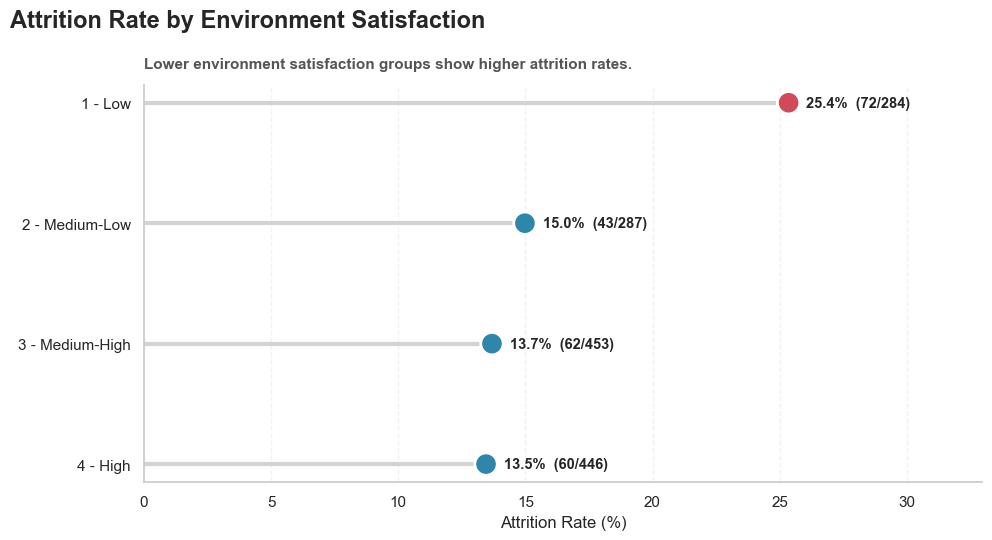

In [36]:
# Step 21: Attrition rate by Environment Satisfaction



# Create summary by EnvironmentSatisfaction score
environment_summary = (
    df_clean
    .groupby("EnvironmentSatisfaction")
    .agg(
        employees=("Attrition", "size"),
        employees_left=("Attrition", "sum"),
        attrition_rate=("Attrition", "mean")
    )
    .reset_index()
)

# Convert attrition rate to percentage
environment_summary["attrition_rate_percent"] = environment_summary["attrition_rate"] * 100

# Add readable labels
environment_labels = {
    1: "1 - Low",
    2: "2 - Medium-Low",
    3: "3 - Medium-High",
    4: "4 - High"
}

environment_summary["Environment Satisfaction"] = (
    environment_summary["EnvironmentSatisfaction"].map(environment_labels)
)

# Sort by attrition rate for ranking
environment_summary = environment_summary.sort_values(
    "attrition_rate_percent",
    ascending=True
).reset_index(drop=True)

display(environment_summary)

# Create figure
fig, ax = plt.subplots(figsize=(10, 5.5))

# Draw horizontal guide lines
ax.hlines(
    y=environment_summary["Environment Satisfaction"],
    xmin=0,
    xmax=environment_summary["attrition_rate_percent"],
    color="#C9C9C9",
    linewidth=3,
    alpha=0.8
)

# Highlight highest attrition group
max_rate = environment_summary["attrition_rate_percent"].max()

colors = [
    "#D1495B" if rate == max_rate else "#2E86AB"
    for rate in environment_summary["attrition_rate_percent"]
]

# Dots
ax.scatter(
    environment_summary["attrition_rate_percent"],
    environment_summary["Environment Satisfaction"],
    s=260,
    color=colors,
    edgecolor="white",
    linewidth=2,
    zorder=3
)

# Labels beside dots
for _, row in environment_summary.iterrows():
    ax.text(
        row["attrition_rate_percent"] + 0.7,
        row["Environment Satisfaction"],
        f"{row['attrition_rate_percent']:.1f}%  ({int(row['employees_left'])}/{int(row['employees'])})",
        va="center",
        fontsize=10.5,
        fontweight="bold"
    )

# Titles
fig.suptitle(
    "Attrition Rate by Environment Satisfaction",
    fontsize=17,
    fontweight="bold",
    x=0.01,
    ha="left"
)

ax.set_title(
    "Lower environment satisfaction groups show higher attrition rates.",
    fontsize=11,
    color="#555555",
    loc="left",
    pad=12
)

# Axis formatting
ax.set_xlabel("Attrition Rate (%)")
ax.set_ylabel("")
ax.set_xlim(0, environment_summary["attrition_rate_percent"].max() * 1.30)

# Clean style
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="x", linestyle="--", alpha=0.25)
ax.grid(axis="y", visible=False)

plt.tight_layout()
plt.show()

<div style="background-color:#111827; color:#ffffff; padding:18px; border-left:6px solid #22c55e; border-radius:8px;">

<h2>🌱 Conclusion: Environment Satisfaction and Attrition</h2>

<p>Employees with <strong>low environment satisfaction</strong> show the highest attrition rate.</p>

<p>This suggests that the work environment is an important attrition-related signal.</p>

</div>

---

## 📊 Attrition Rate by Environment Satisfaction

| Environment Satisfaction Score | Interpretation | Employees Who Left | Total Employees | Attrition Rate |
|---|---|---:|---:|---:|
| 1 | Low | **72** | **284** | **25.4%** |
| 2 | Medium-Low | — | — | **15.0%** |
| 3 | Medium-High | — | — | **13.7%** |
| 4 | High | — | — | **13.5%** |
| Overall Company | — | **237** | **1,470** | **16.12%** |

<div style="background-color:#111827; color:#ffffff; padding:16px; border-left:6px solid #ef4444; border-radius:8px;">

<h3>🚨 Key Insight</h3>

<p>Employees with an environment satisfaction score of <strong>1 - Low</strong> have an attrition rate of <strong>25.4%</strong>.</p>

<p>In this group, <strong>72 out of 284 employees</strong> left the company.</p>

<p>This is much higher than the overall company attrition rate of <strong>16.12%</strong>.</p>

</div>

---

## 📉 Satisfaction Pattern

The attrition rate decreases for higher environment satisfaction scores:

- **15.0%** for Medium-Low
- **13.7%** for Medium-High
- **13.5%** for High

<div style="background-color:#111827; color:#ffffff; padding:16px; border-left:6px solid #f97316; border-radius:8px;">

<h3>📌 Main Pattern</h3>

<p>The biggest attrition risk appears in the lowest environment satisfaction group.</p>

<p>After satisfaction improves above the lowest level, attrition becomes much closer to the company average.</p>

</div>

---

## 🧠 Business Interpretation

This suggests that **environment satisfaction may be an important variable** for understanding employee attrition.

Employees who are less satisfied with their work environment may be more likely to leave because of:

- Poor workplace conditions
- Team or manager-related issues
- Low psychological comfort
- Lack of support
- Poor communication or culture
- Higher day-to-day work friction

<div style="background-color:#111827; color:#ffffff; padding:16px; border-left:6px solid #facc15; border-radius:8px;">

<h3>⚠️ Important Caution</h3>

<p>This should be interpreted as an <strong>association</strong>, not direct proof that environment satisfaction alone causes attrition.</p>

<p>Other factors may also influence employee attrition, such as:</p>

<ul>
<li>Overtime</li>
<li>Job role</li>
<li>Monthly income</li>
<li>Job satisfaction</li>
<li>Work-life balance</li>
<li>Years at company</li>
</ul>

</div>

---

## ✅ Final Takeaway

`EnvironmentSatisfaction` appears to be an important attrition-related variable.

The strongest warning signal is **low environment satisfaction**, especially score **1**, where attrition is clearly higher than the overall company average.


,feature,segment,employees,employees_left,attrition_rate_percent,lift_vs_average
0,Department,Sales,446,92,20.628,1.279
1,AgeBand,26–30,263,56,21.293,1.321
2,JobSatisfactionLabel,Low,289,66,22.837,1.416
3,JobRole,Human Resources,52,12,23.077,1.431
4,JobRole,Laboratory Technician,259,62,23.938,1.485
5,BusinessTravel,Travel_Frequently,277,69,24.910,1.545
6,EnvironmentSatisfactionLabel,Low,284,72,25.352,1.572
7,OverTime,Yes,416,127,30.529,1.894
8,WorkLifeBalanceLabel,Poor,80,25,31.250,1.938
9,YearsAtCompanyBand,0–1,215,75,34.884,2.164


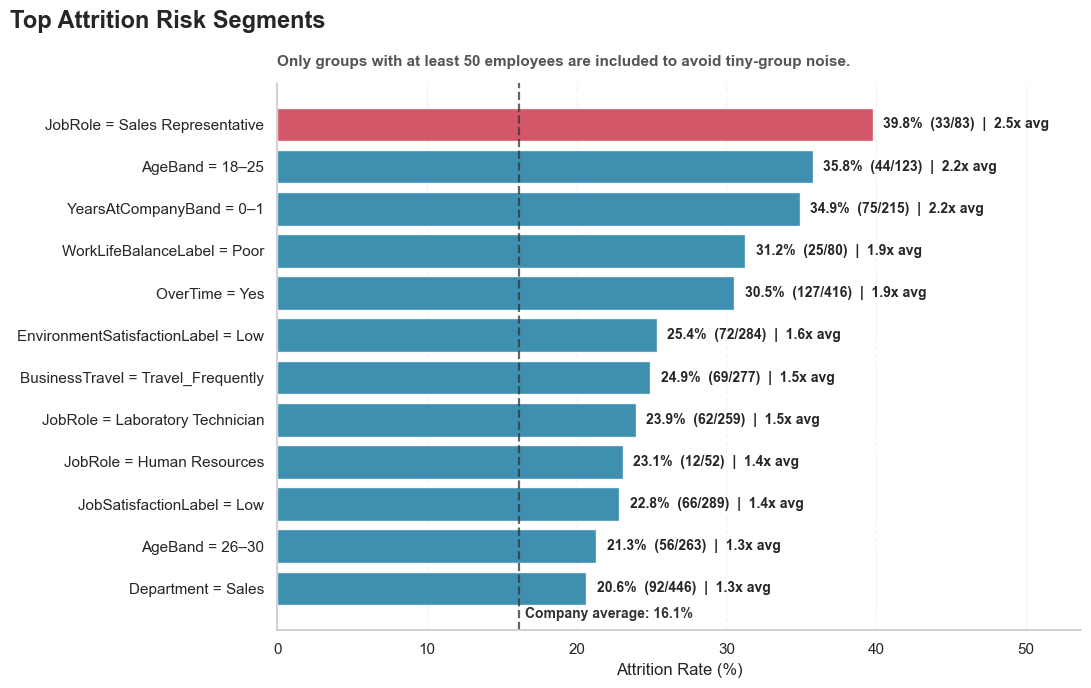

In [37]:
# Step 22: Final EDA summary — Top attrition risk segments


# Overall company attrition rate
overall_attrition_rate = df_clean["Attrition"].mean() * 100

# Create a working copy
risk_data = df_clean.copy()

# Create age bands again
age_bins = [17, 25, 30, 35, 40, 45, 50, 60]
age_labels = ["18–25", "26–30", "31–35", "36–40", "41–45", "46–50", "51–60"]

risk_data["AgeBand"] = pd.cut(
    risk_data["Age"],
    bins=age_bins,
    labels=age_labels
)

# Create years-at-company bands again
tenure_bins = [-1, 1, 3, 5, 10, 20, 40]
tenure_labels = ["0–1", "2–3", "4–5", "6–10", "11–20", "21+"]

risk_data["YearsAtCompanyBand"] = pd.cut(
    risk_data["YearsAtCompany"],
    bins=tenure_bins,
    labels=tenure_labels
)

# Make score columns easier to understand
risk_data["JobSatisfactionLabel"] = risk_data["JobSatisfaction"].map({
    1: "Low",
    2: "Medium-Low",
    3: "Medium-High",
    4: "High"
})

risk_data["EnvironmentSatisfactionLabel"] = risk_data["EnvironmentSatisfaction"].map({
    1: "Low",
    2: "Medium-Low",
    3: "Medium-High",
    4: "High"
})

risk_data["WorkLifeBalanceLabel"] = risk_data["WorkLifeBalance"].map({
    1: "Poor",
    2: "Fair",
    3: "Good",
    4: "Excellent"
})

# Variables we want to summarize
segment_columns = [
    "OverTime",
    "BusinessTravel",
    "Department",
    "JobRole",
    "AgeBand",
    "YearsAtCompanyBand",
    "JobSatisfactionLabel",
    "EnvironmentSatisfactionLabel",
    "WorkLifeBalanceLabel"
]

# Function to calculate attrition rate for each segment
def summarize_segments(data, column):
    summary = (
        data
        .groupby(column, observed=True)
        .agg(
            employees=("Attrition", "size"),
            employees_left=("Attrition", "sum"),
            attrition_rate=("Attrition", "mean")
        )
        .reset_index()
    )
    
    summary["feature"] = column
    summary["segment"] = summary[column].astype(str)
    summary["attrition_rate_percent"] = summary["attrition_rate"] * 100
    summary["lift_vs_average"] = summary["attrition_rate_percent"] / overall_attrition_rate
    
    return summary[[
        "feature",
        "segment",
        "employees",
        "employees_left",
        "attrition_rate_percent",
        "lift_vs_average"
    ]]

# Combine all segment summaries
all_segments = pd.concat(
    [summarize_segments(risk_data, column) for column in segment_columns],
    ignore_index=True
)

# Keep only reasonably sized groups
# This avoids misleading conclusions from tiny groups.
minimum_group_size = 50

top_risk_segments = (
    all_segments
    .query("employees >= @minimum_group_size")
    .sort_values("attrition_rate_percent", ascending=False)
    .head(12)
    .sort_values("attrition_rate_percent", ascending=True)
    .reset_index(drop=True)
)

display(top_risk_segments)

# Create readable label for chart
top_risk_segments["chart_label"] = (
    top_risk_segments["feature"]
    + " = "
    + top_risk_segments["segment"]
)

# Create figure
fig, ax = plt.subplots(figsize=(11, 7))

# Color highest risk group differently
max_rate = top_risk_segments["attrition_rate_percent"].max()

colors = [
    "#D1495B" if rate == max_rate else "#2E86AB"
    for rate in top_risk_segments["attrition_rate_percent"]
]

bars = ax.barh(
    top_risk_segments["chart_label"],
    top_risk_segments["attrition_rate_percent"],
    color=colors,
    alpha=0.92
)

# Add value labels
for bar, rate, left_count, total_count, lift in zip(
    bars,
    top_risk_segments["attrition_rate_percent"],
    top_risk_segments["employees_left"],
    top_risk_segments["employees"],
    top_risk_segments["lift_vs_average"]
):
    ax.text(
        bar.get_width() + 0.7,
        bar.get_y() + bar.get_height() / 2,
        f"{rate:.1f}%  ({int(left_count)}/{int(total_count)})  |  {lift:.1f}x avg",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

# Overall average line
ax.axvline(
    overall_attrition_rate,
    color="#333333",
    linestyle="--",
    linewidth=1.6,
    alpha=0.75
)

ax.text(
    overall_attrition_rate + 0.4,
    -0.7,
    f"Company average: {overall_attrition_rate:.1f}%",
    fontsize=10,
    color="#333333",
    fontweight="bold"
)

# Titles
fig.suptitle(
    "Top Attrition Risk Segments",
    fontsize=17,
    fontweight="bold",
    x=0.01,
    ha="left"
)

ax.set_title(
    f"Only groups with at least {minimum_group_size} employees are included to avoid tiny-group noise.",
    fontsize=11,
    color="#555555",
    loc="left",
    pad=12
)

# Axis formatting
ax.set_xlabel("Attrition Rate (%)")
ax.set_ylabel("")
ax.set_xlim(0, top_risk_segments["attrition_rate_percent"].max() * 1.35)

# Clean style
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="x", linestyle="--", alpha=0.25)
ax.grid(axis="y", visible=False)

plt.tight_layout()
plt.show()

<div style="background-color:#111827; color:#ffffff; padding:18px; border-left:6px solid #ef4444; border-radius:8px;">

<h2>🚨 Conclusion: Top Attrition Risk Segments</h2>

<p>The final EDA summary highlights the employee groups with the <strong>highest attrition rates</strong>.</p>

<p>Only groups with at least <strong>50 employees</strong> were included to avoid misleading conclusions from very small sample sizes.</p>

</div>

---

## 📊 High-Risk Attrition Segments

The overall company attrition rate is **16.1%**.

Several employee groups show much higher attrition rates than this average.

| Risk Segment | Attrition Rate | Business Meaning |
|---|---:|---|
| Sales Representatives | **39.8%** | Highest-risk job role |
| Age 18–25 | **35.8%** | Highest-risk age group |
| 0–1 years at company | **34.9%** | Highest-risk tenure group |
| Poor work-life balance | **31.2%** | Strong work-life risk signal |
| Overtime employees | **30.5%** | High workload risk signal |
| Overall company average | **16.1%** | Baseline comparison |

<div style="background-color:#111827; color:#ffffff; padding:16px; border-left:6px solid #f97316; border-radius:8px;">

<h3>📌 Highest-Risk Group</h3>

<p>The highest-risk group is <strong>Sales Representatives</strong>, with an attrition rate of <strong>39.8%</strong>.</p>

<p>This is about <strong>2.5 times higher</strong> than the overall company average of <strong>16.1%</strong>.</p>

</div>

---

## 🔍 Main Risk Concentration

The analysis shows that attrition risk is **not random**.

It appears to be concentrated among specific employee groups, especially:

- Early-career employees
- Early-tenure employees
- Sales Representatives
- Employees working overtime
- Employees with poor work-life balance
- Employees with low satisfaction scores

<div style="background-color:#111827; color:#ffffff; padding:16px; border-left:6px solid #ef4444; border-radius:8px;">

<h3>🚨 Business Risk Insight</h3>

<p>Several employee groups have attrition rates close to or above <strong>30%</strong>.</p>

<p>These groups should be prioritized for deeper HR analysis and retention planning.</p>

</div>

---

## 🧠 Business Interpretation

These findings suggest that attrition is concentrated around a few important themes:

| Theme | Possible Business Interpretation |
|---|---|
| Early career risk | Younger employees may explore alternatives more often |
| Early tenure risk | Onboarding or expectation mismatch may affect retention |
| Role-based risk | Some roles may face higher pressure or lower satisfaction |
| Workload risk | Overtime may increase stress and burnout risk |
| Work-life balance risk | Poor balance may increase likelihood of leaving |

<div style="background-color:#111827; color:#ffffff; padding:16px; border-left:6px solid #facc15; border-radius:8px;">

<h3>⚠️ Important Caution</h3>

<p>These findings are useful for business understanding, but they should be treated as <strong>associations</strong>, not direct proof of cause.</p>

<p>Other variables may also influence attrition, such as income, department, satisfaction, job level, manager support, and career growth.</p>

</div>

---

## ✅ Transition to Machine Learning

In the next section, we move from **exploratory data analysis** to **machine learning preprocessing**.

The goal is to prepare these variables properly for model training so the model can learn patterns related to employee attrition.

<div style="background-color:#111827; color:#ffffff; padding:16px; border-left:6px solid #22c55e; border-radius:8px;">

<h3>✅ Final Takeaway</h3>

<p>Attrition risk is clearly concentrated in specific employee segments.</p>

<p>The most important segments to monitor are <strong>Sales Representatives, younger employees, early-tenure employees, overtime employees, and employees with poor work-life balance or low satisfaction</strong>.</p>

</div>
